### Smart-Stock TrOCR — Kaggle

In [1]:
# ── Install dependencies ────────────────────────────────────────────────────
!pip install -q transformers==5.0.0 datasets evaluate jiwer albumentations
!pip install -q "peft==0.13.2"
!pip install -q "torchao>=0.16.0"
!pip install -q optuna

import os
from pathlib import Path

# ── Kaggle paths ─────────────────────────────────────────────────────────────
# Input datasets are mounted read-only at /kaggle/input/
# All outputs (checkpoints, saved models) go to /kaggle/working/ — persists after session
# We also copy final model back to /kaggle/working/trocr-smart-stock-best for download

INPUT_DIR   = Path("/kaggle/input")
WORKING_DIR = Path("/kaggle/working")

# smart-stock-dataset (your Kaggle dataset with smart_stock_dataset_v2)
DATASET_DIR = Path("/kaggle/input/datasets/maazahmad69/smart-stock-dataset/smart_stock_dataset_v2")

# trocr-smart-stock-best model (uploaded as a separate Kaggle dataset)
MODEL_INPUT = Path("/kaggle/input/datasets/maazahmad69/trocr-smart-stock-best/content/drive/MyDrive/SmartStock/trocr-smart-stock-best")

# Output dirs — writable
CHECKPOINT_DIR = WORKING_DIR / "trocr-smart-stock"
BEST_MODEL_DIR = WORKING_DIR / "trocr-smart-stock-best"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset dir : {DATASET_DIR}")
print(f"Model input : {MODEL_INPUT}")
print(f"Checkpoints : {CHECKPOINT_DIR}")
print(f"Best model  : {BEST_MODEL_DIR}")

# Verify model files present
for f in ["config.json", "model.safetensors", "generation_config.json"]:
    exists = (MODEL_INPUT / f).exists()
    print(f"  {'✅' if exists else '❌'} {f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/3.1 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━ 1.7/3.1 MB 49.8 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 43.6 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/320.7 kB ? eta -:--:--

...

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/3.2 MB ? eta -:--:--

   ━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.4/3.2 MB 11.8 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.5 MB/s eta 0:00:00


Dataset dir : /kaggle/input/datasets/maazahmad69/smart-stock-dataset/smart_stock_dataset_v2
Model input : /kaggle/input/datasets/maazahmad69/trocr-smart-stock-best/content/drive/MyDrive/SmartStock/trocr-smart-stock-best
Checkpoints : /kaggle/working/trocr-smart-stock
Best model  : /kaggle/working/trocr-smart-stock-best
  ✅ config.json
  ✅ model.safetensors
  ✅ generation_config.json


#### **CORD's ground_truth** field is a raw JSON string. Parse it and construct a flat text target from the menu array.

In [2]:
import json
from collections import defaultdict
from PIL import Image

def extract_cord_crops(image: Image.Image, ground_truth_str: str) -> list:
    try:
        data = json.loads(ground_truth_str)
    except (json.JSONDecodeError, AttributeError):
        return []

    valid_lines = data.get("valid_line", [])
    if not valid_lines:
        return []

    groups = defaultdict(list)
    for line in valid_lines:
        groups[line["group_id"]].append(line)

    w, h = image.size
    crops = []

    for gid, lines in groups.items():
        if not any(l.get("category", "").startswith("menu.") for l in lines):
            continue

        all_words, all_xs, all_ys = [], [], []
        for line in lines:
            for word in line.get("words", []):
                text = word.get("text", "").strip()
                if text:
                    all_words.append(text)
                q = word.get("quad", {})
                if q:
                    all_xs += [q.get("x1",0), q.get("x2",0), q.get("x3",0), q.get("x4",0)]
                    all_ys += [q.get("y1",0), q.get("y2",0), q.get("y3",0), q.get("y4",0)]

        if not all_words or not all_xs:
            continue

        text = " ".join(all_words)
        x1, y1 = max(0, min(all_xs)), max(0, min(all_ys))
        x2, y2 = min(w, max(all_xs)), min(h, max(all_ys))
        if x2 <= x1 or y2 <= y1:
            continue

        crops.append((image.crop((x1, y1, x2, y2)), text))

    return crops

### **SROIE** Text Reconstruction
#### SROIE has bboxes per word. Group words by Y-coordinate (within 15px = same line), merge bounding boxes per line, crop each line region.

In [3]:
def extract_sroie_crops(image: Image.Image, words: list, bboxes: list) -> list:
    if not words or not bboxes:
        return []

    items = sorted(zip(words, bboxes), key=lambda x: x[1][1])

    lines = []
    current_words, current_boxes = [items[0][0]], [items[0][1]]
    for word, box in items[1:]:
        if abs(box[1] - current_boxes[-1][1]) <= 15:
            current_words.append(word)
            current_boxes.append(box)
        else:
            lines.append((current_words, current_boxes))
            current_words, current_boxes = [word], [box]
    lines.append((current_words, current_boxes))

    w, h = image.size
    crops = []
    for line_words, line_boxes in lines:
        text = " ".join(line_words).strip()
        if not text:
            continue
        x1 = max(0, min(b[0] for b in line_boxes))
        y1 = max(0, min(b[1] for b in line_boxes))
        x2 = min(w, max(b[2] for b in line_boxes))
        y2 = min(h, max(b[3] for b in line_boxes))
        if x2 <= x1 or y2 <= y1:
            continue
        crops.append((image.crop((x1, y1, x2, y2)), text))
    return crops

### Combined Dataset Builder
OOM fix: Images encoded to PNG bytes immediately. Line crops: Each receipt yields multiple (crop, text) pairs. SROIE 2x weighting: SROIE train concatenated twice.

In [4]:
import io
from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets

# Check if pre-built dataset exists in Kaggle input (uploaded as dataset)
# Falls back to building from HuggingFace if not found
DATASET_SAVE = DATASET_DIR

def pil_to_bytes(img: Image.Image) -> bytes:
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="PNG")
    return buf.getvalue()

def iter_to_dataset(iterator) -> Dataset:
    img_bytes, texts = [], []
    for img, text in iterator:
        img_bytes.append(pil_to_bytes(img))
        texts.append(text)
    return Dataset.from_dict({"image_bytes": img_bytes, "text": texts})

def build_and_save_dataset():
    if DATASET_SAVE.exists():
        print(f"Dataset found at {DATASET_SAVE} — loading from disk...")
        return DatasetDict.load_from_disk(str(DATASET_SAVE))

    print("Building line-crop dataset from scratch...")

    print("Loading CORD...")
    cord = load_dataset("naver-clova-ix/cord-v2")

    def cord_iter(split):
        for ex in cord[split]:
            for crop, text in extract_cord_crops(ex["image"], ex["ground_truth"]):
                yield crop, text

    cord_train      = iter_to_dataset(cord_iter("train"))
    cord_validation = iter_to_dataset(cord_iter("validation"))
    cord_test       = iter_to_dataset(cord_iter("test"))
    print(f"  CORD train: {len(cord_train)} | val: {len(cord_validation)} | test: {len(cord_test)}")
    del cord

    print("Loading SROIE...")
    sroie = load_dataset("sizhkhy/SROIE")

    def sroie_iter(split):
        for ex in sroie[split]:
            for crop, text in extract_sroie_crops(ex["images"], ex["words"], ex["bboxes"]):
                yield crop, text

    sroie_train = iter_to_dataset(sroie_iter("train"))
    sroie_test  = iter_to_dataset(sroie_iter("test"))
    print(f"  SROIE train: {len(sroie_train)} | test: {len(sroie_test)}")
    del sroie

    dataset_dict = DatasetDict({
        "train":      concatenate_datasets([cord_train, sroie_train, sroie_train]),
        "validation": cord_validation,
        "test":       concatenate_datasets([cord_test, sroie_test]),
    })

    # Save to working dir (writable) — download later if needed
    save_path = WORKING_DIR / "smart_stock_dataset_v2"
    dataset_dict.save_to_disk(str(save_path))
    print(f"✅ Saved to {save_path}")
    print(f"   Train:      {len(dataset_dict['train'])}")
    print(f"   Validation: {len(dataset_dict['validation'])}")
    print(f"   Test:       {len(dataset_dict['test'])}")
    return dataset_dict

combined_dataset = build_and_save_dataset()

Dataset found at /kaggle/input/datasets/maazahmad69/smart-stock-dataset/smart_stock_dataset_v2 — loading from disk...


#### **Augmentation**
Apply augmentation only to training images, inline during the preprocess_trocr step.

In [5]:
import albumentations as A
import cv2
import numpy as np
from PIL import Image, ImageOps

receipt_augmentation = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=(-0.4, 0.15), p=0.6),
    A.GaussNoise(p=0.5),
    A.Rotate(limit=8, border_mode=cv2.BORDER_REPLICATE, p=0.5),
    A.Perspective(scale=(0.02, 0.08), p=0.4),
    A.MotionBlur(blur_limit=5, p=0.3),
    A.ImageCompression(p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.RandomShadow(p=0.2),
])

def apply_augmentation(pil_image: Image.Image) -> Image.Image:
    """Pad tiny line crops to min 32px height, then augment."""
    pil_image = pil_image.convert("RGB")
    if pil_image.height < 32:
        pad = 32 - pil_image.height
        pil_image = ImageOps.expand(pil_image, border=(0, pad//2, 0, pad - pad//2), fill=255)
    img_np = np.array(pil_image)
    augmented = receipt_augmentation(image=img_np)["image"]
    return Image.fromarray(augmented)

### Preprocessing Function

In [6]:
import io
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")

def preprocess_trocr(example, augment: bool = False):
    image = Image.open(io.BytesIO(example["image_bytes"])).convert("RGB")

    if augment:
        image = apply_augmentation(image)

    pixel_values = processor(images=image, return_tensors="pt").pixel_values

    labels = processor.tokenizer(
        example["text"],
        padding="max_length",
        max_length=128,
        truncation=True,
    ).input_ids

    labels = [
        t if t != processor.tokenizer.pad_token_id else -100
        for t in labels
    ]

    return {
        "pixel_values": pixel_values.squeeze(),
        "labels": torch.tensor(labels, dtype=torch.long),
    }


class TrOCRDataset(TorchDataset):
    def __init__(self, hf_dataset, augment: bool = False):
        self.data    = hf_dataset
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return preprocess_trocr(self.data[idx], augment=self.augment)


train_dataset = TrOCRDataset(combined_dataset["train"],      augment=True)
val_dataset   = TrOCRDataset(combined_dataset["validation"], augment=False)
test_dataset  = TrOCRDataset(combined_dataset["test"],       augment=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Train: 31057 | Val: 221 | Test: 8301


### Model Setup

In [7]:
from pathlib import Path
from transformers import VisionEncoderDecoderModel
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

# Input checkpoint dir from your uploaded dataset
INPUT_CHECKPOINT_DIR = Path("/kaggle/input/smart-stock-dataset/trocr-smart-stock")

base_model = VisionEncoderDecoderModel.from_pretrained(str(MODEL_INPUT))

for param in base_model.encoder.parameters():
    param.requires_grad = False

# Priority order:
# 1. Working dir checkpoints (current session, most recent)
# 2. Input dir checkpoints (uploaded from Colab — fallback)
# 3. Fresh LoRA (no prior training)

def find_lora_checkpoints(directory: Path):
    """Find checkpoints with LoRA adapter weights in either format."""
    return sorted([
        ckpt for ckpt in directory.glob("checkpoint-*")
        if (ckpt / "lora_adapter").exists() or (ckpt / "adapter_config.json").exists()
    ])

working_checkpoints = find_lora_checkpoints(CHECKPOINT_DIR)
input_checkpoints   = find_lora_checkpoints(INPUT_CHECKPOINT_DIR) if INPUT_CHECKPOINT_DIR.exists() else []

if working_checkpoints:
    latest = working_checkpoints[-1]
    adapter_path = latest / "lora_adapter" if (latest / "lora_adapter").exists() else latest
    model = PeftModel.from_pretrained(base_model, str(adapter_path), is_trainable=True)
    print(f"Resumed from working dir: {adapter_path}")
elif input_checkpoints:
    latest = input_checkpoints[-1]
    adapter_path = latest / "lora_adapter" if (latest / "lora_adapter").exists() else latest
    model = PeftModel.from_pretrained(base_model, str(adapter_path), is_trainable=True)
    print(f"Resumed from input dir: {adapter_path}")
else:
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM,
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        target_modules=["q_proj", "v_proj"],
        bias="none",
    )
    model = get_peft_model(base_model, lora_config)
    model.print_trainable_parameters()
    print("No adapter checkpoint found — fresh LoRA applied")

model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size
model.generation_config.eos_token_id         = processor.tokenizer.sep_token_id
model.generation_config.early_stopping       = True
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.length_penalty       = 2.0
model.generation_config.num_beams            = 4

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

trainable params: 1,523,712 || all params: 335,445,504 || trainable%: 0.4542
No adapter checkpoint found — fresh LoRA applied


In [8]:
def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels       = torch.stack([item["labels"]       for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

### Training Arguments

In [9]:
# from transformers import Seq2SeqTrainingArguments

# training_args = Seq2SeqTrainingArguments(
#     output_dir=str(CHECKPOINT_DIR),   # /kaggle/working/trocr-smart-stock

#     num_train_epochs=5,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,

#     # Hardcoded from Optuna best (Trial 3 of latest run)
#     learning_rate=1.695e-4,
#     warmup_ratio=0.0866,
#     weight_decay=0.01,
#     lr_scheduler_type="cosine",
#     max_grad_norm=1.0,

#     eval_strategy="epoch",
#     save_strategy="steps",
#     save_steps=500,
#     load_best_model_at_end=False,
#     save_total_limit=5,

#     predict_with_generate=True,
#     generation_max_length=128,

#     fp16=True,
#     dataloader_num_workers=2,

#     logging_dir=str(WORKING_DIR / "logs"),
#     logging_steps=50,
#     log_level="info",
#     report_to="none",
# )

##### Technique 1 — Force single GPU + fix LR (most important, run first)

DataParallel doubled effective batch size silently. Forcing single GPU makes real training match Optuna's conditions exactly.

In [10]:
import os
from transformers import Seq2SeqTrainingArguments

# Force single GPU — Optuna tuned at batch size 4 on single GPU.
# DataParallel was silently running batch size 16 (4x mismatch).
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

training_args = Seq2SeqTrainingArguments(
    output_dir=str(CHECKPOINT_DIR),

    num_train_epochs=8,                # more epochs — single GPU converges slower but cleaner
    per_device_train_batch_size=8,     # effective batch = 8 now (no DataParallel)
    per_device_eval_batch_size=8,

    # Optuna best from Kaggle run (Trial 0 — CER 0.088 on subset)
    learning_rate=1.4824e-4,
    warmup_ratio=0.02672,
    weight_decay=0.01,
    # lr_scheduler_type="cosine",

    # Technique 3 Cosine with restarts scheduler

    lr_scheduler_type="cosine_with_restarts",
    # Also add:
    lr_scheduler_kwargs={"num_cycles": 2},   # 2 restarts over total training

    
    max_grad_norm=1.0,

    eval_strategy="epoch",
    save_strategy="steps",
    save_steps=500,
    load_best_model_at_end=False,
    save_total_limit=5,

    predict_with_generate=True,
    generation_max_length=128,

    fp16=True,
    dataloader_num_workers=2,

    logging_dir=str(WORKING_DIR / "logs"),
    logging_steps=50,
    log_level="info",
    report_to="none",

    # Technique 2 (Gradient Accumulation)   Only use if Technique 1 fails
    # gradient_accumulation_steps=2,        # effective batch = 8 × 2 = 16, but LR stays valid
                                           # because accumulation doesn't change the optimizer step rate
                                           # the way DataParallel does
)

print(f"Effective batch size: {training_args.per_device_train_batch_size}")
print(f"GPU count visible: {os.environ.get('CUDA_VISIBLE_DEVICES')}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Effective batch size: 8
GPU count visible: 0


### Metrics

In [11]:
!pip install jiwer -q

In [12]:
import numpy as np
from jiwer import cer, wer

def compute_metrics(pred):
    pred_ids   = pred.predictions
    labels_ids = pred.label_ids

    if pred_ids.dtype != np.int64 and pred_ids.ndim == 3:
        pred_ids = np.argmax(pred_ids, axis=-1)

    vocab_size = processor.tokenizer.vocab_size
    pred_ids   = np.clip(pred_ids, 0, vocab_size - 1)

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)

    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    return {
        "cer": round(cer(label_str, pred_str), 4),
        "wer": round(wer(label_str, pred_str), 4),
    }

### Hyperparameter Search with **Optuna**
After the first clean training run with line crops, use Optuna (Bayesian optimization) via HuggingFace built-in hyperparameter_search to find optimal values.

In [13]:
# import gc
# import copy
# from transformers import Seq2SeqTrainer
# from peft import LoraConfig, get_peft_model, TaskType

# def optuna_hp_space(trial):
#     return {
#         "learning_rate": trial.suggest_float("learning_rate", 1e-4, 5e-4, log=True),
#         "warmup_ratio":  trial.suggest_float("warmup_ratio", 0.0, 0.1),
#     }

# def model_init():
#     gc.collect()
#     torch.cuda.empty_cache()

#     m = VisionEncoderDecoderModel.from_pretrained(str(MODEL_INPUT))

#     for param in m.encoder.parameters():
#         param.requires_grad = False

#     lora_config = LoraConfig(
#         task_type=TaskType.SEQ_2_SEQ_LM,
#         r=16,
#         lora_alpha=32,
#         lora_dropout=0.05,
#         target_modules=["q_proj", "v_proj"],
#         bias="none",
#     )
#     m = get_peft_model(m, lora_config)

#     m.config.decoder_start_token_id = processor.tokenizer.cls_token_id
#     m.config.pad_token_id           = processor.tokenizer.pad_token_id
#     m.config.vocab_size             = m.config.decoder.vocab_size
#     m.generation_config.eos_token_id         = processor.tokenizer.sep_token_id
#     m.generation_config.early_stopping       = True
#     m.generation_config.no_repeat_ngram_size = 3
#     m.generation_config.length_penalty       = 2.0
#     m.generation_config.num_beams            = 4
#     return m

# search_args = copy.deepcopy(training_args)
# search_args.num_train_epochs = 1
# search_args.predict_with_generate = True
# search_args.eval_accumulation_steps = 4
# search_args.dataloader_num_workers = 0
# search_args.per_device_train_batch_size = 4
# search_args.per_device_eval_batch_size = 4
# search_args.output_dir = str(WORKING_DIR / "optuna_search")
# search_args.save_strategy = "no"
# search_args.load_best_model_at_end = False
# search_args.eval_strategy = "epoch"
# search_args.logging_steps = 50

# search_val_hf = combined_dataset["validation"].select(range(min(200, len(combined_dataset["validation"]))))
# search_val = TrOCRDataset(search_val_hf, augment=False)

# search_hf = combined_dataset["train"].select(range(len(combined_dataset["train"]) // 8))
# search_train = TrOCRDataset(search_hf, augment=True)

# search_trainer = Seq2SeqTrainer(
#     model_init=model_init,
#     args=search_args,
#     train_dataset=search_train,
#     eval_dataset=search_val,
#     data_collator=collate_fn,
#     compute_metrics=compute_metrics,
# )

# best_run = search_trainer.hyperparameter_search(
#     direction="minimize",
#     backend="optuna",
#     hp_space=optuna_hp_space,
#     n_trials=4,
# )

# del search_trainer
# gc.collect()
# torch.cuda.empty_cache()

# print("Best hyperparameters:", best_run.hyperparameters)
# for k, v in best_run.hyperparameters.items():
#     setattr(training_args, k, v)
# training_args.predict_with_generate = True
# print("Updated training_args:", training_args.learning_rate, training_args.warmup_ratio)

### Trainer and Training

In [14]:
from transformers import Seq2SeqTrainer, TrainerCallback
import shutil

class LoRASaveCallback(TrainerCallback):
    """
    Saves LoRA adapter weights alongside each Trainer checkpoint.
    Without this, PEFT checkpoints reload base model config instead
    of adapter state, causing effective weight reset on resume.
    """
    def on_save(self, args, state, control, **kwargs):
        checkpoint_dir = Path(args.output_dir) / f"checkpoint-{state.global_step}"
        adapter_dir = checkpoint_dir / "lora_adapter"
        adapter_dir.mkdir(parents=True, exist_ok=True)
        kwargs["model"].save_pretrained(str(adapter_dir))
        print(f"LoRA adapter saved to {adapter_dir}")
        return control

print(f"LR: {training_args.learning_rate}")
print(f"Warmup ratio: {training_args.warmup_ratio}")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")

# Remove old checkpoints (no lora_adapter subdir) to avoid interference
if CHECKPOINT_DIR.exists():
    for ckpt in CHECKPOINT_DIR.glob("checkpoint-*"):
        has_adapter = (ckpt / "lora_adapter").exists()
        if not has_adapter:
            shutil.rmtree(ckpt)
            print(f"Removed stale checkpoint (no LoRA adapter): {ckpt}")

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    callbacks=[LoRASaveCallback()],
)

# Resume from latest valid checkpoint if available
valid_checkpoints = sorted(CHECKPOINT_DIR.glob("checkpoint-*"))
resume_from = str(valid_checkpoints[-1]) if valid_checkpoints else None

if resume_from:
    print(f"Resuming from: {resume_from}")
else:
    print("Starting fresh training")

trainer.train(resume_from_checkpoint=resume_from)

LR: 0.00014824
Warmup ratio: 0.02672
Epochs: 8
Batch size: 8


***** Running training *****


  Num examples = 31,057


  Num Epochs = 8


  Instantaneous batch size per device = 8


...

  Batch size = 16


LoRA adapter saved to /kaggle/working/trocr-smart-stock/checkpoint-15536/lora_adapter


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]




Training completed. Do not forget to share your model on huggingface.co/models =)




TrainOutput(global_step=15536, training_loss=1.9436368878420547, metrics={'train_runtime': 20011.3655, 'train_samples_per_second': 12.416, 'train_steps_per_second': 0.776, 'total_flos': 1.8692076323931056e+20, 'train_loss': 1.9436368878420547, 'epoch': 8.0})

### Training Curves

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)
print(history.columns)
history.head()

Index(['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss',
       'eval_cer', 'eval_wer', 'eval_runtime', 'eval_samples_per_second',
       'eval_steps_per_second', 'train_runtime', 'train_samples_per_second',
       'train_steps_per_second', 'total_flos', 'train_loss'],
      dtype='object')


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_cer,eval_wer,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.885075,1.305614,0.000017,0.025747,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.991956,1.201042,0.000035,0.051493,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.962527,1.182356,0.000053,0.077240,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.035073,1.295369,0.000071,0.102987,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.960951,1.352449,0.000089,0.128733,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


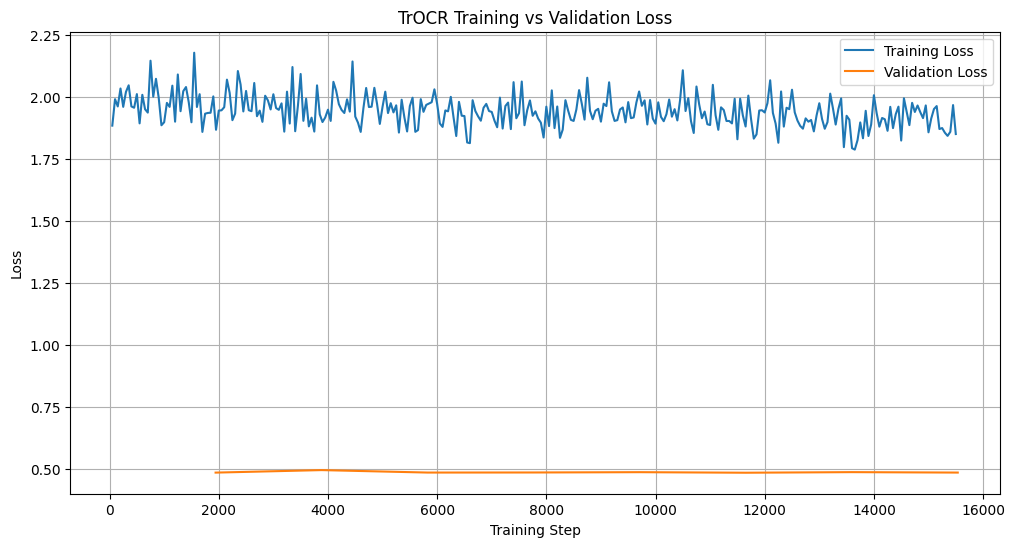

In [16]:
train_logs = history[history["loss"].notna()]
eval_logs  = history[history["eval_loss"].notna()]

plt.figure(figsize=(12,6))
plt.plot(train_logs["step"], train_logs["loss"], label="Training Loss")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("TrOCR Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

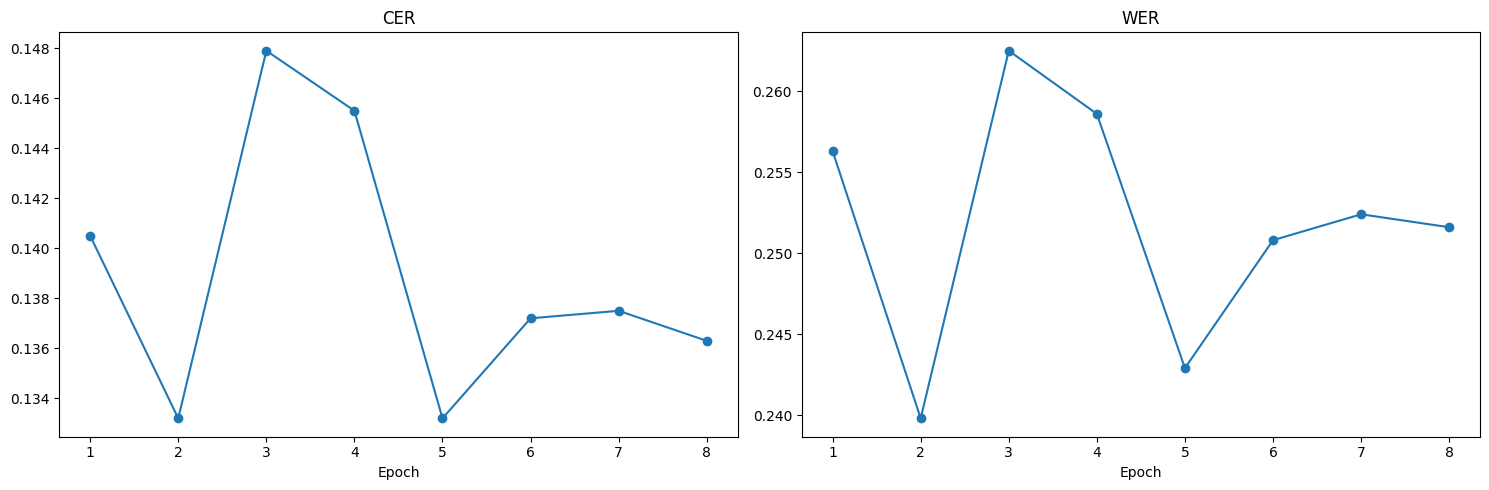

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
axes[0].plot(eval_logs["epoch"], eval_logs["eval_cer"], marker="o")
axes[0].set_title("CER")
axes[0].set_xlabel("Epoch")
axes[1].plot(eval_logs["epoch"], eval_logs["eval_wer"], marker="o")
axes[1].set_title("WER")
axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

In [18]:
summary = eval_logs[["epoch", "eval_loss", "eval_cer", "eval_wer"]]
summary

,epoch,eval_loss,eval_cer,eval_wer
38,1.0,0.483462,0.1405,0.2563
78,2.0,0.493602,0.1332,0.2398
118,3.0,0.483656,0.1479,0.2625
158,4.0,0.483974,0.1455,0.2586
198,5.0,0.485218,0.1332,0.2429
238,6.0,0.482999,0.1372,0.2508
277,7.0,0.485375,0.1375,0.2524
317,8.0,0.483605,0.1363,0.2516


### Save & Export

In [19]:
from peft import PeftModel

merged_model = model.merge_and_unload()

for save_path in [str(BEST_MODEL_DIR)]:
    merged_model.save_pretrained(save_path)
    processor.save_pretrained(save_path)
    merged_model.generation_config.save_pretrained(save_path)
    print(f"Saved to: {save_path}")

expected_files = [
    "model.safetensors", "config.json", "generation_config.json",
    "tokenizer_config.json", "tokenizer.json", "processor_config.json",
]
print(f"\nVerification ({BEST_MODEL_DIR}):")
for fname in expected_files:
    fpath = BEST_MODEL_DIR / fname
    exists = fpath.exists()
    size = fpath.stat().st_size / 1e6 if exists else 0
    print(f"  {'✅' if exists else '❌'} {fname} ({size:.1f} MB)")

Configuration saved in /kaggle/working/trocr-smart-stock-best/config.json


Configuration saved in /kaggle/working/trocr-smart-stock-best/generation_config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /kaggle/working/trocr-smart-stock-best/model.safetensors


tokenizer config file saved in /kaggle/working/trocr-smart-stock-best/tokenizer_config.json


processor saved in /kaggle/working/trocr-smart-stock-best/processor_config.json


Configuration saved in /kaggle/working/trocr-smart-stock-best/generation_config.json


Saved to: /kaggle/working/trocr-smart-stock-best

Verification (/kaggle/working/trocr-smart-stock-best):
  ✅ model.safetensors (1335.7 MB)
  ✅ config.json (0.0 MB)
  ✅ generation_config.json (0.0 MB)
  ✅ tokenizer_config.json (0.0 MB)
  ✅ tokenizer.json (3.6 MB)
  ✅ processor_config.json (0.0 MB)


### Evaluate on Test Set

In [20]:
results = trainer.evaluate(test_dataset)
print(f"Test CER: {results['eval_cer']:.4f}")
print(f"Test WER: {results['eval_wer']:.4f}")

# Target benchmarks:
# CER <= 0.05 (5%)
# WER <= 0.10 (10%)


***** Running Evaluation *****


  Num examples = 8301


  Batch size = 16


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


The channel dimension is ambiguous. Got image shape torch.Size([3, 42, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


### Qualitative Evaluation

In [ ]:
import io
from PIL import Image

sample = combined_dataset["test"][0]
image = Image.open(io.BytesIO(sample["image_bytes"])).convert("RGB")

pixel_values = processor(
    image,
    return_tensors="pt"
).pixel_values.to(model.device)

generated_ids = model.generate(pixel_values)

prediction = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("GROUND TRUTH:")
print(sample["text"])
print("")
print("="*80)
print("PREDICTION:")
print(prediction)

image